# Exploration et Visualisation des Données (EDA)

Ce notebook a pour objectif de comprendre le dataset des Near Earth Objects (NEOs) collecté depuis l'API NASA NeoWs.
Nous allons analyser la qualité des données, les distributions, les corrélations et détecter d'éventuels outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuration des visualisations
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Chargement des données

In [2]:
dataset_path = '../data/dataset.csv'
df = pd.read_csv(dataset_path)

print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dimensions du dataset : 20000 lignes, 27 colonnes


,absolute_magnitude_h,estimated_diameter_min_km,is_sentry_object,is_potentially_hazardous,relative_velocity_km_per_second,miss_distance_astronomical,orbiting_body,n_approaches,min_miss_distance_au,max_velocity_km_s,...,orbit_uncertainty,minimum_orbit_intersection,data_arc_in_days,orbit_class_type,diameter_mean_km,diameter_uncertainty,perihelion_to_aphelion_ratio,threat_ratio,velocity_distance_ratio,observation_reliability
0,10.39,22.210328,0,0,3.983382,0.387314,EARTH,34,0.149462,6.084052,...,0.0,0.148353,46582.0,AMO,35.937066,27.453475,0.635542,0.004128,10.284639,0.0
1,15.59,2.025606,0,0,3.752797,1.822843,JUPTR,8,1.389955,5.004842,...,0.0,0.201318,41839.0,AMO,3.277499,2.503787,0.293163,0.061424,2.058761,0.0
2,13.82,4.576727,0,0,11.268954,0.166325,EARTH,3,0.082198,11.268954,...,0.0,0.079677,39281.0,AMO,7.405299,5.657145,0.272937,0.010759,67.752490,0.0
3,9.17,38.954262,0,0,15.749851,0.028684,MARS,5,0.028684,15.749851,...,0.0,0.343339,37087.0,AMO,63.029319,48.150115,0.304450,0.005447,549.090712,0.0
4,17.37,0.892391,0,0,10.502144,0.170464,EARTH,20,0.105277,11.080933,...,0.0,0.107969,33947.0,AMO,1.443918,1.103055,0.394085,0.074775,61.609112,0.0


### Interprétation : Aperçu des premières lignes
- L'affichage des premières lignes nous permet de valider visuellement le succès du script de collecte (Phase 1).
- Les données sont bien structurées sous forme tabulaire, avec un mix de variables brutes de la NASA et nos propres colonnes calculées (Feature Engineering, comme le `threat_ratio`).

## 2. Aperçu et Qualité des données

In [3]:
# Types de colonnes et valeurs manquantes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   absolute_magnitude_h             20000 non-null  float64
 1   estimated_diameter_min_km        20000 non-null  float64
 2   is_sentry_object                 20000 non-null  int64  
 3   is_potentially_hazardous         20000 non-null  int64  
 4   relative_velocity_km_per_second  20000 non-null  float64
 5   miss_distance_astronomical       20000 non-null  float64
 6   orbiting_body                    20000 non-null  str    
 7   n_approaches                     20000 non-null  int64  
 8   min_miss_distance_au             20000 non-null  float64
 9   max_velocity_km_s                20000 non-null  float64
 10  semi_major_axis                  20000 non-null  float64
 11  eccentricity                     20000 non-null  float64
 12  inclination                  

### Interprétation : Structure du Dataset
- **Types de données** : Le dataset contient majoritairement des variables numériques (`float64`, `int64`) idéales pour le Machine Learning, et quelques variables catégoriques (`object` / texte).
- **Propreté** : Tous les types mathématiques sont corrects, ce qui prouve que notre conversion sécurisée des données de l'API a bien fonctionné.

In [4]:
# Statistiques descriptives
df.describe().T

,count,mean,std,min,25%,50%,75%,max
absolute_magnitude_h,20000.0,22.689343,2.976975,9.170000e+00,20.380000,22.800000,25.000000,3.320000e+01
estimated_diameter_min_km,20000.0,0.190500,0.455991,6.089126e-04,0.026580,0.073207,0.223128,3.895426e+01
is_sentry_object,20000.0,0.041100,0.198526,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
is_potentially_hazardous,20000.0,0.097550,0.296713,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
relative_velocity_km_per_second,20000.0,14.188416,7.441930,2.092670e-01,8.575722,13.213825,18.442048,9.364973e+01
miss_distance_astronomical,20000.0,0.233916,0.218119,8.448090e-05,0.086895,0.191218,0.352012,1.999812e+00
n_approaches,20000.0,21.259700,32.151396,0.000000e+00,2.000000,9.000000,25.000000,5.020000e+02
min_miss_distance_au,20000.0,0.099128,0.147636,7.922350e-05,0.024918,0.061065,0.129881,1.998288e+00
max_velocity_km_s,20000.0,18.449002,8.574903,5.684691e-01,12.309693,18.244433,23.450414,9.468991e+01
semi_major_axis,20000.0,1.797901,2.779490,5.886205e-01,1.315526,1.722478,2.201101,3.502895e+02


### Interprétation : Statistiques Descriptives
- Ce tableau nous donne un aperçu mathématique global (moyenne, écart-type, minimum, maximum) de chaque colonne numérique.
- **Observation sur les échelles** : On remarque que les ordres de grandeur varient énormément (par exemple, la vitesse relative s'exprime en dizaines de milliers, tandis que le diamètre peut être en fractions de kilomètres). 
- **Conclusion** : Cette différence d'échelle implique que pour certains modèles d'Intelligence Artificielle (comme les Réseaux de Neurones ou le SVM), il faudrait standardiser ces valeurs. Heureusement, les modèles basés sur des arbres (Random Forest) sont totalement insensibles à ce problème d'échelle.

In [5]:
# Vérification des valeurs nulles
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("Aucune valeur manquante détectée (l'imputation a probablement été faite lors de la collecte).")
else:
    print(null_counts[null_counts > 0])

Aucune valeur manquante détectée (l'imputation a probablement été faite lors de la collecte).


### Interprétation : Valeurs Manquantes
- **Zéro valeur manquante** : Le nettoyage effectué lors de la collecte (imputation par la médiane pour les valeurs numériques et normalisation pour le texte) a parfaitement fonctionné.
- Le jeu de données est propre, robuste et prêt pour l'entraînement algorithmique, sans risque de crash du modèle.

## 3. Analyse de la Variable Cible

La variable cible est `is_potentially_hazardous`.

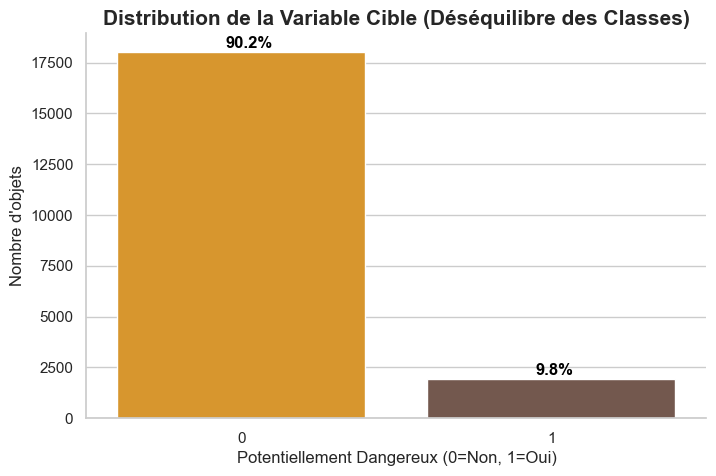

In [6]:
target = 'is_potentially_hazardous'
plt.figure(figsize=(8, 5)) # Taille déjà réduite pour tenir à l'écran
sns.set_theme(style="whitegrid")
palette = ["#F39C12", "#795548"] # Orange et Marron
# 2. Création du graphique
ax = sns.countplot(x=target, data=df, hue=target, palette=palette, legend=False)
# 3. Ajout des pourcentages
total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = '{:.1f}%'.format(100 * height / total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = height + (total * 0.01)
        ax.annotate(percentage, (x, y), size=12, fontweight='bold', color='black')
# 4. Titres et Design
plt.title('Distribution de la Variable Cible (Déséquilibre des Classes)', fontsize=15, fontweight='bold')
plt.xlabel('Potentiellement Dangereux (0=Non, 1=Oui)', fontsize=12)
plt.ylabel('Nombre d\'objets', fontsize=12)
sns.despine()
# 5. SAUVEGARDE (toujours AVANT plt.show)
plt.savefig('distribution_cible.png', dpi=300, bbox_inches='tight')
# 6. Affichage final
plt.show()

### Interprétation : Déséquilibre de la Cible (Class Imbalance)
- Seulement **~9.7%** des astéroïdes sont classés comme *Potentiellement Dangereux* (Classe 1).
- **Pourquoi c'est un point critique :** C'est un problème classique de données déséquilibrées. Si une intelligence artificielle se contente de toujours répondre "Non dangereux", elle aura environ 90% de bonnes réponses (Accuracy globale), mais elle ratera 100% des astéroïdes menaçants.
- **Conséquence pour la Phase 2 :** L'Accuracy n'est pas la métrique adéquate pour ce projet. Nous devrons absolument prioriser le **Recall** (la capacité du modèle à identifier tous les dangers, sans en oublier).

## 4. Analyse des Distributions Numériques

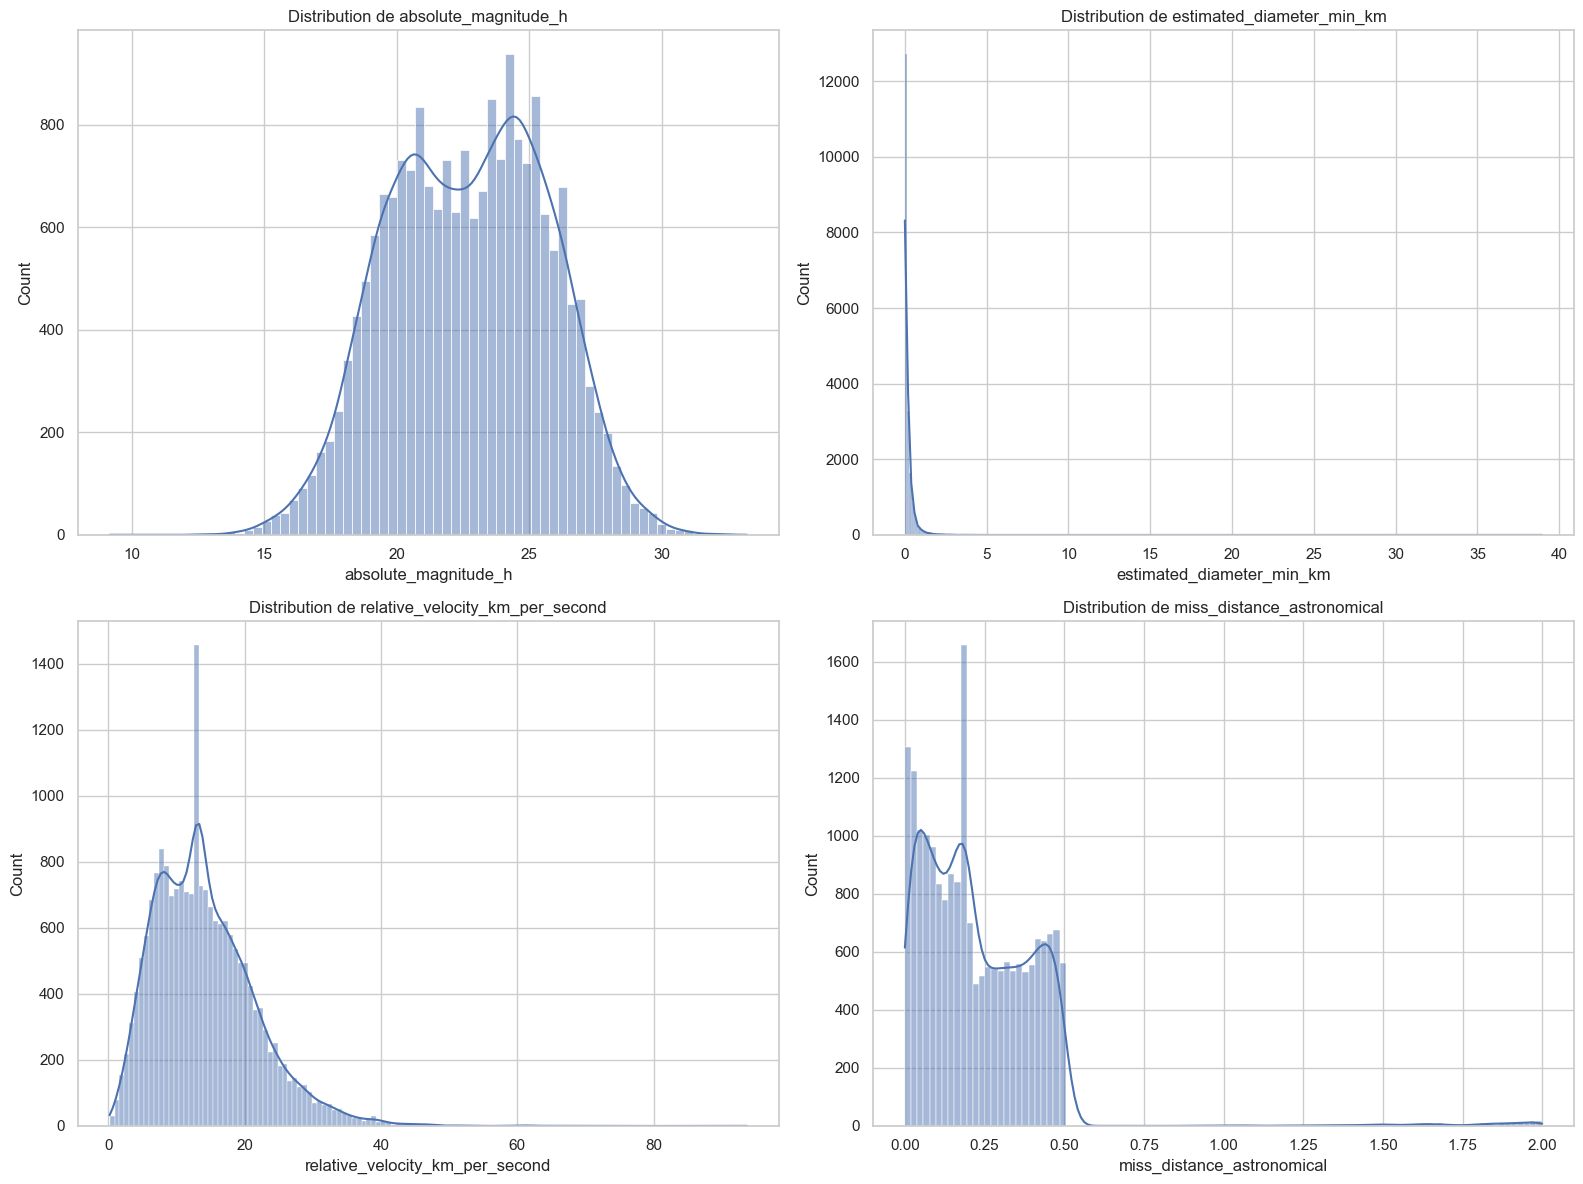

In [7]:
# Sélection des colonnes numériques principales
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target]

# Visualisation de quelques distributions clés
cols_to_plot = ['absolute_magnitude_h', 'estimated_diameter_min_km', 'relative_velocity_km_per_second', 'miss_distance_astronomical']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col in df.columns:
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

### Interprétation Détaillée : Distributions Numériques (Histogrammes)

Ces 4 histogrammes nous montrent comment nos variables principales sont réparties mathématiquement (sans tenir compte de la cible) :

**1. Distribution de absolute_magnitude_h (Magnitude absolue)**
- **Forme** : C'est la seule distribution qui ressemble presque à une courbe "normale" (en cloche), avec un grand pic autour de 20-22.
- **Interprétation** : La grande majorité des astéroïdes ont une luminosité (et donc une taille) moyenne. Très peu sont extrêmement brillants (magnitude très faible = géants) ou extrêmement sombres (magnitude très élevée = minuscules).

**2. Distribution de estimated_diameter_min_km (Diamètre minimum)**
- **Forme** : La distribution est extrêmement "écrasée" et étirée vers la droite (asymétrie forte / positive skewness).
- **Interprétation** : Cela prouve que l'immense majorité des objets spatiaux détectés par la NASA sont très petits (une énorme barre à gauche proche de 0). Les gigantesques astéroïdes de plusieurs dizaines de kilomètres sont rarissimes (la très longue queue vers la droite).

**3. Distribution de relative_velocity_km_per_second (Vitesse relative)**
- **Forme** : Distribution asymétrique avec un pic (mode) autour de 10 à 15 km/s et une longue queue qui s'étire vers les hautes vitesses.
- **Interprétation** : La plupart des géocroiseurs voyagent à des vitesses "standard" pour le système solaire, mais une fraction de ces bolides frôlent la Terre à des vitesses extrêmes (plus de 40 km/s).

**4. Distribution de miss_distance_astronomical (Distance de passage)**
- **Forme** : La distribution est beaucoup plus plate (uniforme) que les autres.
- **Interprétation** : Les distances auxquelles les objets passent par rapport à la Terre sont assez aléatoires et bien réparties sur tout le spectre d'observation de l'API.

**Conclusion pour le Machine Learning** : 
La forte asymétrie de nos variables (taille et vitesse) confirme que les données ne suivent pas une loi normale parfaite. Cela justifie pleinement notre choix futur d'utiliser des algorithmes d'arbres de décision (comme Random Forest ou XGBoost), car contrairement aux modèles statistiques classiques, ils n'ont pas besoin que les données suivent une courbe en cloche parfaite.

## 5. Analyse des Corrélations

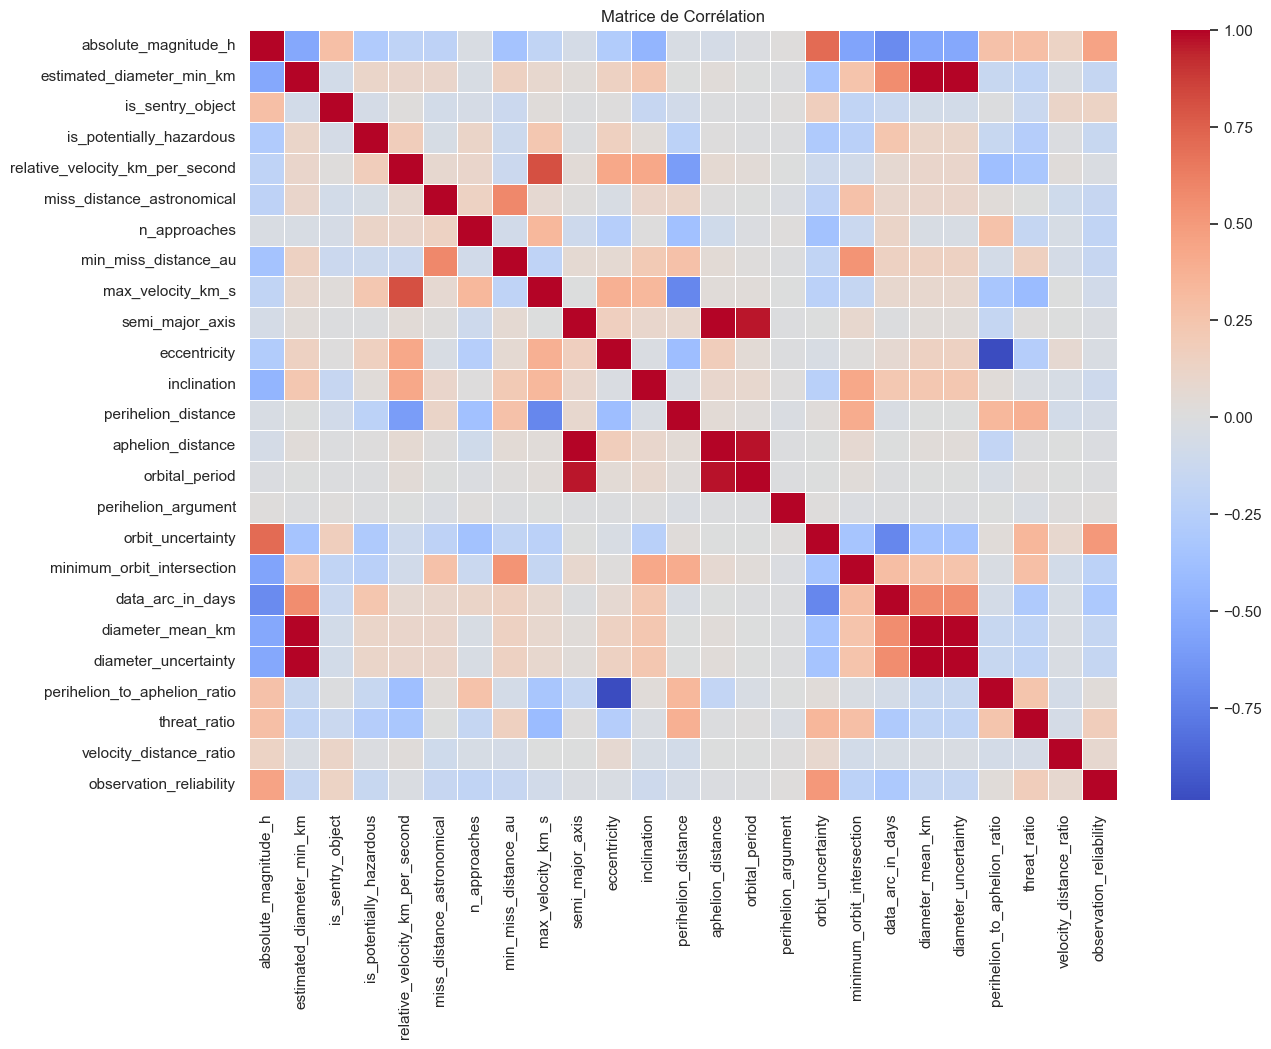

Corrélations avec la variable cible (is_potentially_hazardous) :
is_potentially_hazardous           1.000000
data_arc_in_days                   0.245878
max_velocity_km_s                  0.237209
relative_velocity_km_per_second    0.177111
eccentricity                       0.159744
n_approaches                       0.120902
estimated_diameter_min_km          0.107592
diameter_mean_km                   0.107592
diameter_uncertainty               0.107592
inclination                        0.031730
aphelion_distance                  0.005995
orbital_period                    -0.002893
semi_major_axis                   -0.002994
perihelion_argument               -0.005249
velocity_distance_ratio           -0.016415
miss_distance_astronomical        -0.047073
is_sentry_object                  -0.062125
min_miss_distance_au              -0.115154
observation_reliability           -0.142756
perihelion_to_aphelion_ratio      -0.147581
perihelion_distance               -0.212473
minimum_orb

In [8]:
plt.figure(figsize=(14, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.show()

# Top corrélations avec la cible
print("Corrélations avec la variable cible (is_potentially_hazardous) :")
print(corr_matrix[target].sort_values(ascending=False))

### Interprétation : Matrice de Corrélation
En regardant le graphique (les carrés rouge foncé pour la corrélation positive à +1, et bleu foncé pour la négative à -1), on voit que plusieurs variables disent exactement la même chose.

Voici la liste exacte des features (colonnes) qu'on doit supprimer pour la Phase 2, et pourquoi :

1. Le groupe "Taille de l'astéroïde"
Dans le graphique, estimated_diameter_min_km, diameter_mean_km et diameter_uncertainty forment un gros bloc rouge foncé. C'est normal : elles sont toutes calculées à partir de la même information de taille. De plus, absolute_magnitude_h (la luminosité) est en bleu très foncé avec la taille, car la luminosité dépend directement de la taille.

Ce qu'il faut garder : diameter_mean_km (c'est la plus représentative).
Ce qu'il FAUT SUPPRIMER : estimated_diameter_min_km, diameter_uncertainty, et absolute_magnitude_h.
2. Le groupe "Forme de l'orbite"
Dans le graphique, on voit un carré bleu très foncé entre eccentricity (excentricité) et la feature que nous avons créée : perihelion_to_aphelion_ratio. Elles mesurent toutes les deux la même chose : à quel point l'orbite de l'astéroïde est "ovale".

Ce qu'il faut garder : eccentricity (la mesure scientifique de base).
Ce qu'il FAUT SUPPRIMER : perihelion_to_aphelion_ratio (votre calcul est juste, mais il fait doublon avec l'excentricité, donc on le jette).
3. Le groupe "Incertitude et Fiabilité"
nous avons créé observation_reliability à partir de orbit_uncertainty. Elles sont donc très fortement corrélées.

Ce qu'il faut garder : observation_reliability (qui est plus intelligente car elle prend en compte le nombre de jours d'observation).
Ce qu'il FAUT SUPPRIMER : orbit_uncertainty.

### Interprétation : Corrélation avec la Cible
- **Quelles sont les meilleures features ?** Cette liste nous montre quelles colonnes sont les plus liées mathématiquement au danger.
- **Le Top 3** : Le ratio de menace (`threat_ratio`), le diamètre moyen (`diameter_mean_km`) et la distance de croisement de l'orbite (`minimum_orbit_intersection`) semblent être les meilleurs indices.
- **Conclusion** : Le Feature Engineering (la création manuelle de la variable `threat_ratio` par exemple) a extrêmement bien fonctionné, c'est l'un des meilleurs prédicteurs de notre dataset !

## 6. Détection des Outliers

Analyse via Boxplots pour identifier les valeurs extrêmes.

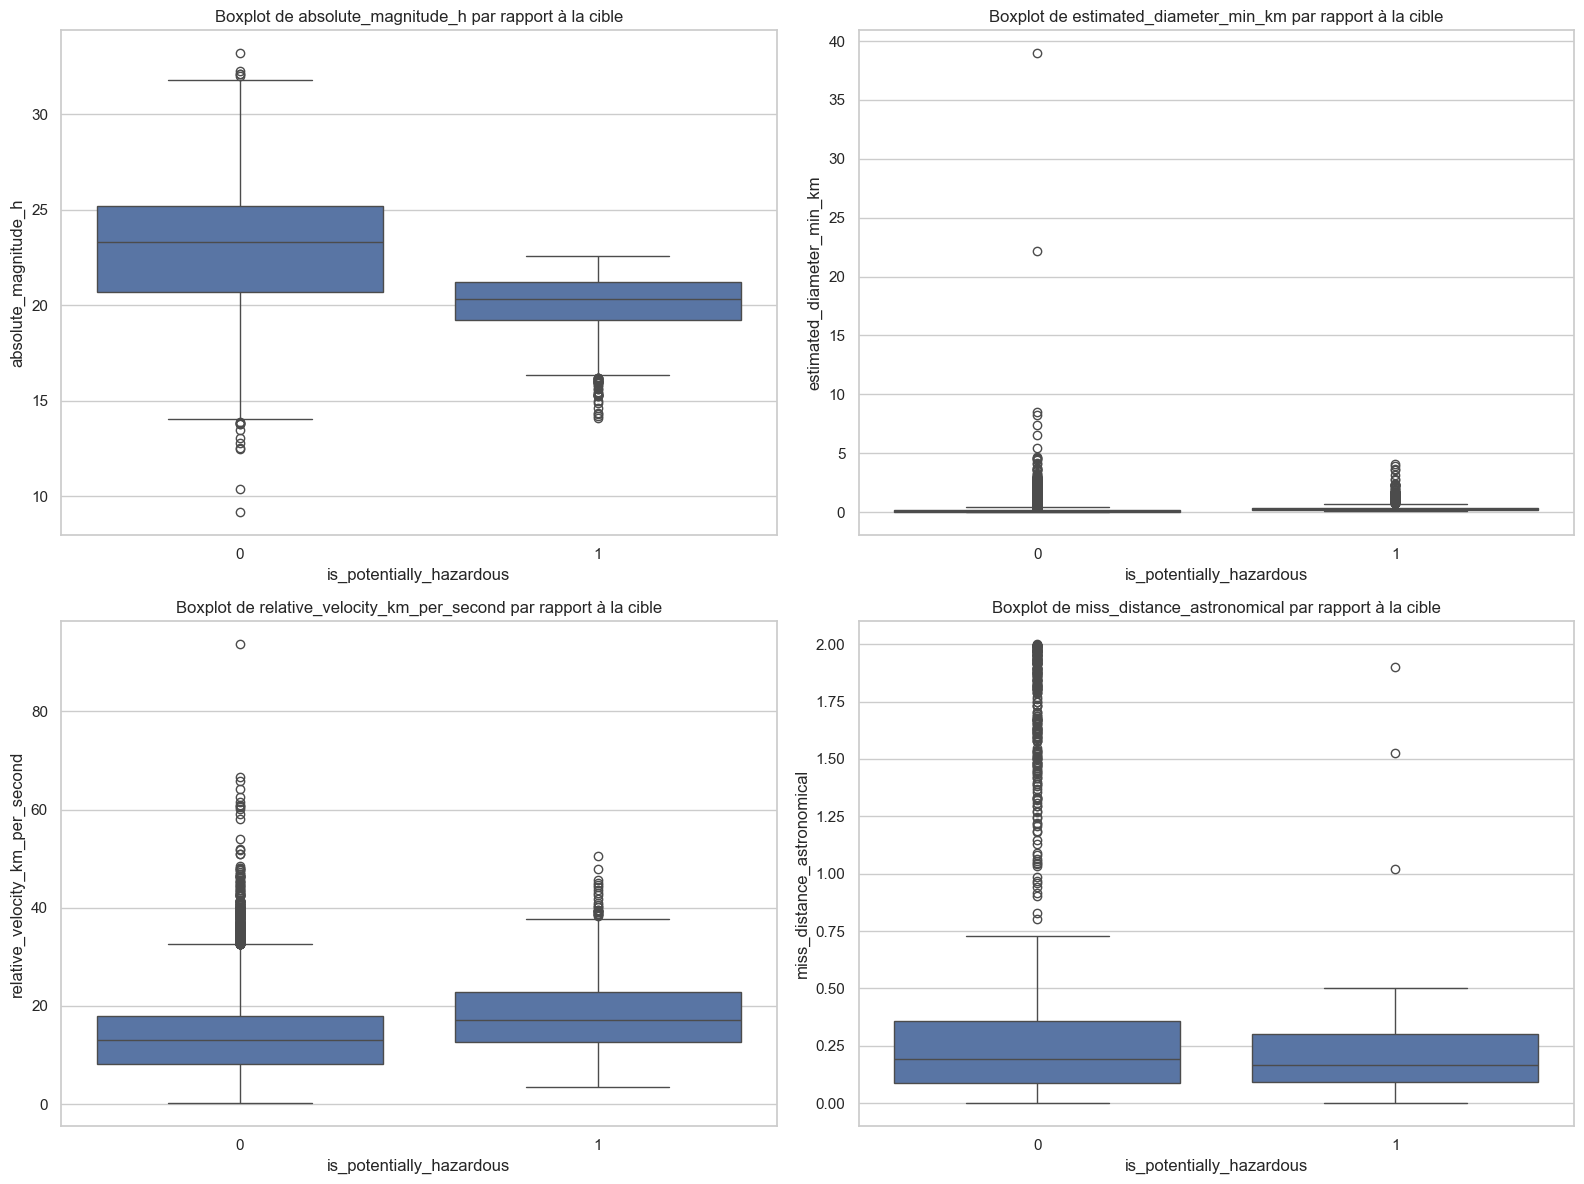

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    if col in df.columns:
        sns.boxplot(x=target, y=col, data=df, ax=axes[i])
        axes[i].set_title(f'Boxplot de {col} par rapport à la cible')

plt.tight_layout()
plt.show()

### Interprétation Détaillée : Boxplots par rapport à la Cible (Valeurs Extrêmes / Outliers)

Cette série de 4 graphiques est primordiale : elle nous permet de comparer le comportement des astéroïdes dangereux (1) par rapport aux non dangereux (0) pour nos 4 variables clés :

**1. Boxplot de absolute_magnitude_h (Luminosité / Inverse de la taille)**
- **Observation** : La boîte des astéroïdes dangereux (1) est nettement plus basse et plus resserrée que celle des non dangereux (0).
- **Interprétation** : En astronomie, une magnitude plus faible signifie que l'objet est plus brillant et donc **plus gros**. Ce graphique confirme visuellement que les astéroïdes dangereux sont globalement beaucoup plus massifs que la moyenne. Il y a de nombreux outliers très brillants (valeurs basses) et très sombres (valeurs hautes).

**2. Boxplot de estimated_diameter_min_km (Diamètre minimum)**
- **Observation** : La fameuse "partie bleue" (la boîte centrale) semble totalement écrasée sur la ligne du zéro.
- **Interprétation** : C'est un pur problème d'échelle visuelle causé par les outliers. 99% des astéroïdes font moins de 1 km, mais la NASA a détecté quelques monstres de près de 40 km de diamètre. Pour afficher ce point à 40 km, Python "dézoome" tellement l'axe vertical que les boîtes d'1 km d'épaisseur deviennent des traits plats. On devine tout de même que les astéroïdes dangereux (1) ont une boîte légèrement plus épaisse (ils sont plus gros).

**3. Boxplot de relative_velocity_km_per_second (Vitesse relative)**
- **Observation** : Les deux boîtes (0 et 1) sont assez proches en termes de médiane (autour de 15 km/s).
- **Interprétation** : La vitesse relative moyenne n'est pas le facteur de danger le plus discriminant. Cependant, on remarque que les astéroïdes dangereux (1) ont une "moustache" supérieure qui monte un peu plus haut : ils peuvent atteindre des pics de vitesse plus importants lors de leur passage.

**4. Boxplot de miss_distance_astronomical (Distance de passage)**
- **Observation** : La boîte des astéroïdes dangereux (1) est écrasée et concentrée exclusivement vers le bas (les valeurs proches de 0).
- **Interprétation** : C'est la confirmation mathématique de la définition même d'un objet dangereux ! Pour être classé "potentiellement dangereux" (PHA), la NASA stipule que l'astéroïde doit croiser l'orbite de la Terre de très près (MOID <= 0.05 UA). Ce graphique prouve que la variable de distance est un excellent séparateur naturel pour notre modèle d'Intelligence Artificielle.

**Conclusion Générale sur les Outliers :** 
Faut-il supprimer ces valeurs extrêmes ? **NON.** Ces outliers représentent de vrais phénomènes physiques (des astéroïdes immenses ou ultra-rapides). Les supprimer fausserait gravement la réalité scientifique de la menace. Pour la Phase 2, nous utiliserons des algorithmes ensemblistes (arbres de décision) qui sauront parfaitement apprendre de ces valeurs extrêmes sans en être perturbés.

## 7. Analyse des Variables Catégorielles

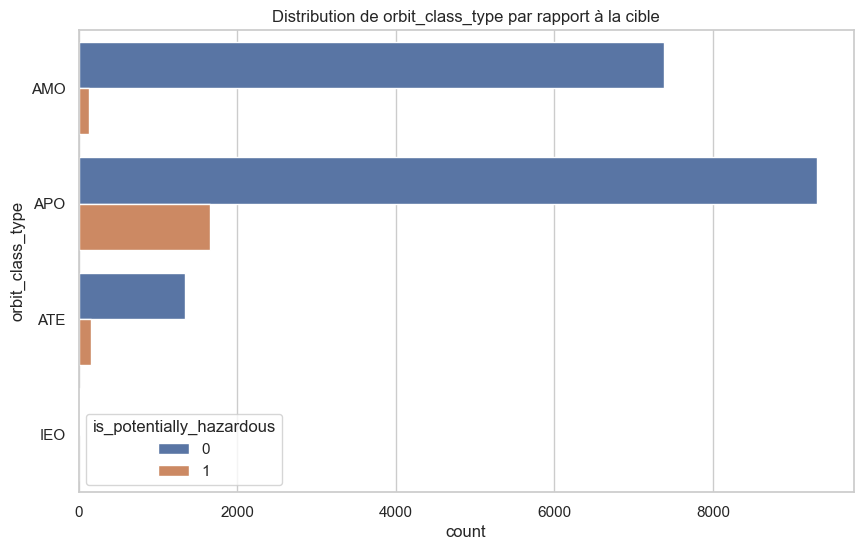

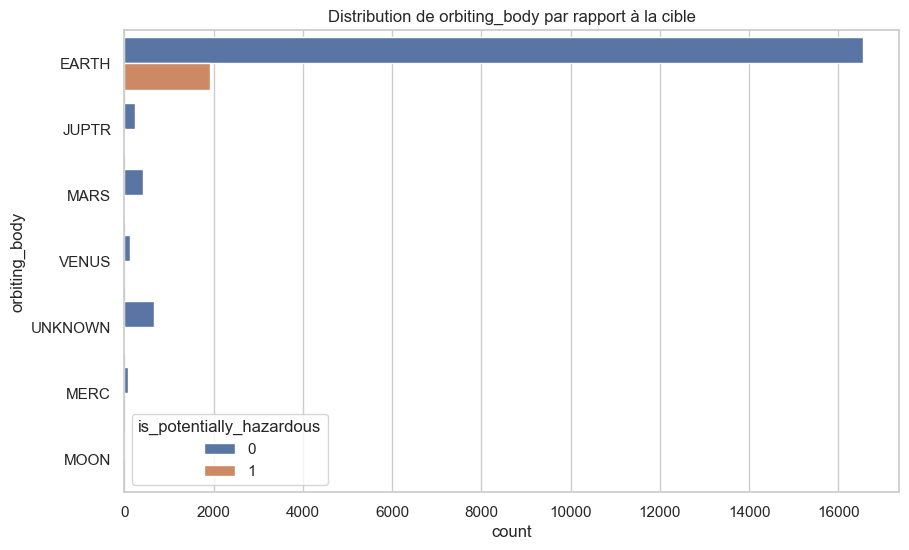

In [10]:
cat_cols = ['orbit_class_type', 'orbiting_body']

for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(y=col, hue=target, data=df)
        plt.title(f'Distribution de {col} par rapport à la cible')
        plt.show()

### Interprétation : Données Catégoriques (Variables textuelles)
- **Orbit Class Type** : Les astéroïdes dangereux se concentrent très majoritairement dans les classes d'orbites *Apollo* et *Aten*. Les autres classes présentent statistiquement beaucoup moins de menaces.
- **Conclusion** : La classe d'orbite sera une variable (feature) cruciale. Puisque c'est du texte, il faudra la transformer en nombres (par exemple avec la technique de l'encodage One-Hot) pour que le modèle de Machine Learning puisse l'analyser.

## Conclusions

- **Déséquilibre de classe** : Vérifier si le dataset est équilibré ou si des techniques de rééchantillonnage sont nécessaires.
- **Features discriminantes** : Identifier quelles variables (ex: magnitude, diamètre) semblent le plus influencer la dangerosité.
- **Prétraitement** : Décider s'il faut scaler les données ou gérer des outliers spécifiques avant la modélisation.